# CSCI 440 - Project 4: German Credit Risk Classification with Keras MLPs

**Objectives:**
- Train deep MLPs with Keras
- Use TensorBoard for visualization
- Fine-tune neural network hyperparameters with Keras Tuner

## 0. Install / Import Dependencies

In [2]:
# %pip install -r requirements.txt

In [3]:
import sys
print(sys.executable)

/Users/jon/Projects/sp26/Proj 4/CSCI-440-project-4/.venv/bin/python


In [4]:
import os
import datetime
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')

TensorFlow : 2.21.0
Keras      : 3.14.0


---
## 1. Data Preparation

### 1.1 Load & Inspect

In [5]:
df = pd.read_csv('German-credit.csv')
print('Shape:', df.shape)
df.head()

Shape: (1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,good
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,bad


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   checking_status         1000 non-null   object 
 1   duration                1000 non-null   float64
 2   credit_history          1000 non-null   object 
 3   purpose                 1000 non-null   object 
 4   credit_amount           1000 non-null   float64
 5   savings_status          1000 non-null   object 
 6   employment              1000 non-null   object 
 7   installment_commitment  1000 non-null   float64
 8   personal_status         1000 non-null   object 
 9   other_parties           1000 non-null   object 
 10  residence_since         1000 non-null   float64
 11  property_magnitude      1000 non-null   object 
 12  age                     1000 non-null   float64
 13  other_payment_plans     1000 non-null   object 
 14  housing                 1000 non-null   o

In [7]:
df.describe(include='all')

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
count,1000,1000.000000,1000,1000,1000.000000,1000,1000,1000.000000,1000,1000,...,1000,1000.000000,1000,1000,1000.000000,1000,1000.000000,1000,1000,1000
unique,4,NaN,5,10,NaN,5,5,NaN,4,3,...,4,NaN,3,3,NaN,4,NaN,2,2,2
top,no checking,NaN,existing paid,radio/tv,NaN,<100,1<=X<4,NaN,male single,none,...,car,NaN,none,own,NaN,skilled,NaN,none,yes,good
freq,394,NaN,530,280,NaN,603,339,NaN,548,907,...,332,NaN,814,713,NaN,630,NaN,596,963,700
mean,NaN,20.903000,NaN,NaN,3271.258000,NaN,NaN,2.973000,NaN,NaN,...,NaN,35.546000,NaN,NaN,1.407000,NaN,1.155000,NaN,NaN,NaN
std,NaN,12.058814,NaN,NaN,2822.736876,NaN,NaN,1.118715,NaN,NaN,...,NaN,11.375469,NaN,NaN,0.577654,NaN,0.362086,NaN,NaN,NaN
min,NaN,4.000000,NaN,NaN,250.000000,NaN,NaN,1.000000,NaN,NaN,...,NaN,19.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,NaN
25%,NaN,12.000000,NaN,NaN,1365.500000,NaN,NaN,2.000000,NaN,NaN,...,NaN,27.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,NaN
50%,NaN,18.000000,NaN,NaN,2319.500000,NaN,NaN,3.000000,NaN,NaN,...,NaN,33.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,NaN
75%,NaN,24.000000,NaN,NaN,3972.250000,NaN,NaN,4.000000,NaN,NaN,...,NaN,42.000000,NaN,NaN,2.000000,NaN,1.000000,NaN,NaN,NaN


Missing values per column:
checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
class                     0
dtype: int64

Class distribution:
class
good    700
bad     300
Name: count, dtype: int64


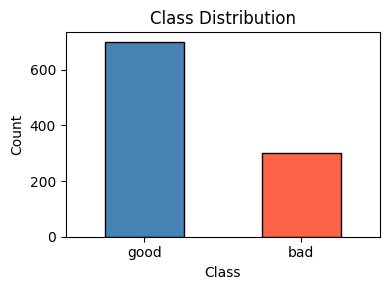

In [8]:
print('Missing values per column:')
print(df.isnull().sum())
print('\nClass distribution:')
print(df['class'].value_counts())

fig, ax = plt.subplots(figsize=(4, 3))
df['class'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black')
ax.set_title('Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

### 1.2 Encode Categorical Features

In [9]:
categorical_cols = df.select_dtypes(include='object').columns.drop('class').tolist()
numerical_cols   = df.select_dtypes(include='number').columns.tolist()

print('Categorical features:', categorical_cols)
print('Numerical features  :', numerical_cols)

Categorical features: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']
Numerical features  : ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']


In [10]:
# One-hot encode all categorical features
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

# Binary-encode the target
df_encoded['target'] = (df_encoded['class'] == 'good').astype(int)
df_encoded.drop(columns=['class'], inplace=True)

print('Encoded shape:', df_encoded.shape)
df_encoded.head(3)

Encoded shape: (1000, 62)


,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,checking_status_0<=X<200,checking_status_<0,checking_status_>=200,...,housing_rent,job_high qualif/self emp/mgmt,job_skilled,job_unemp/unskilled non res,job_unskilled resident,own_telephone_none,own_telephone_yes,foreign_worker_no,foreign_worker_yes,target
0,6.0,1169.0,4.0,4.0,67.0,2.0,1.0,False,True,False,...,False,False,True,False,False,False,True,False,True,1
1,48.0,5951.0,2.0,2.0,22.0,1.0,1.0,True,False,False,...,False,False,True,False,False,True,False,False,True,0
2,12.0,2096.0,2.0,3.0,49.0,1.0,2.0,False,False,False,...,False,False,False,False,True,True,False,False,True,1


### 1.3 Feature / Target Split, Scale & Train–Test Split

In [11]:
X = df_encoded.drop(columns=['target']).values.astype(np.float32)
y = df_encoded['target'].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numerical features (fit on training set only)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]}  |  features: {X_train.shape[1]}')
print(f'Test samples     : {X_test.shape[0]}  |  features: {X_test.shape[1]}')
print(f'Positive rate (train): {y_train.mean():.3f}   (test): {y_test.mean():.3f}')

Training samples : 800  |  features: 61
Test samples     : 200  |  features: 61
Positive rate (train): 0.700   (test): 0.700


---
## 2. Model Building

### 2.1 Architecture Rationale (per pp. 349–353 / Table 10-2)

| Hyperparameter | Choice | Reasoning |
|---|---|---|
| Hidden layers | **2** | Good starting point; complex enough for tabular data |
| Neurons / layer | **128** | Same width in all layers ("stretch-pants"); regularised with Dropout |
| Activation | **ReLU** | Default recommended activation for hidden layers |
| Output neurons | **1** | Binary classification |
| Output activation | **Sigmoid** | Binary cross-entropy requires probability output |
| Loss | **Binary Cross-Entropy** | Standard for binary classification (Table 10-2) |
| Optimizer | **Adam** | Solid default (p. 351) |
| Learning rate | **1e-3** | Typical starting point; later tuned with Keras Tuner |
| Regularisation | **Dropout (0.3)** | Prevents overfitting instead of shrinking layer sizes |
| Stopping | **EarlyStopping** | Avoids manual epoch tuning (p. 353) |

### 2.2 Build the Baseline MLP

In [12]:
def build_baseline_model(input_dim, learning_rate=1e-3):
    """Two-hidden-layer MLP for binary classification."""
    model = keras.Sequential([
        keras.Input(shape=(input_dim,), name='input'),

        # Hidden layer 1
        layers.Dense(128, activation='relu', name='hidden_1'),
        layers.BatchNormalization(name='bn_1'),
        layers.Dropout(0.3, name='dropout_1'),

        # Hidden layer 2
        layers.Dense(128, activation='relu', name='hidden_2'),
        layers.BatchNormalization(name='bn_2'),
        layers.Dropout(0.3, name='dropout_2'),

        # Output layer
        layers.Dense(1, activation='sigmoid', name='output'),
    ], name='German_Credit_MLP')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model


baseline_model = build_baseline_model(input_dim=X_train.shape[1])
print('Model built successfully.')

Model built successfully.


### 2.3 Model Summary

In [13]:
# Standard summary: layer name, output shape, param count
baseline_model.summary()

Model: "German_Credit_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,601 (100.00 KB)

 Trainable params: 25,089 (98.00 KB)

 Non-trainable params: 512 (2.00 KB)

In [14]:
# Detailed per-layer parameter listing
print(f"{'Layer':<20} {'Output Shape':<20} {'# Params':>10}")
print('-' * 52)
total_params = 0
trainable_params = 0
non_trainable_params = 0

for layer in baseline_model.layers:
    out_shape = str(layer.output.shape)
    n_params  = layer.count_params()
    n_train   = sum(tf.size(w).numpy() for w in layer.trainable_weights)
    n_non     = sum(tf.size(w).numpy() for w in layer.non_trainable_weights)
    total_params       += n_params
    trainable_params   += n_train
    non_trainable_params += n_non
    print(f"{layer.name:<20} {out_shape:<20} {n_params:>10,}")

print('=' * 52)
print(f"{'Total params':<40} {total_params:>10,}")
print(f"{'Trainable params':<40} {trainable_params:>10,}")
print(f"{'Non-trainable params':<40} {non_trainable_params:>10,}")

Layer                Output Shape           # Params
----------------------------------------------------
hidden_1             (None, 128)               7,936
bn_1                 (None, 128)                 512
dropout_1            (None, 128)                   0
hidden_2             (None, 128)              16,512
bn_2                 (None, 128)                 512
dropout_2            (None, 128)                   0
output               (None, 1)                   129
Total params                                 25,601
Trainable params                             25,089
Non-trainable params                            512


In [15]:
# Print every weight tensor (name + shape + values) for full parameter inspection
print('\n=== All Model Weights (name | shape | values) ===\n')
for layer in baseline_model.layers:
    weights = layer.get_weights()
    if weights:
        print(f'--- Layer: {layer.name} ---')
        for w, wt in zip(layer.weights, weights):
            print(f'  {w.name}  shape={wt.shape}')
            print(f'  {wt}\n')


=== All Model Weights (name | shape | values) ===

--- Layer: hidden_1 ---
  kernel  shape=(61, 128)
  [[ 0.02085595 -0.00563735 -0.08988307 ...  0.128366    0.00651541
   0.04209274]
 [ 0.03403725  0.02515417 -0.1376274  ... -0.17564894 -0.14019005
  -0.05482346]
 [-0.17728107 -0.15639503 -0.0665626  ... -0.03127201 -0.10755443
  -0.1309556 ]
 ...
 [ 0.12314019 -0.01350364  0.05881475 ...  0.13019532  0.11147818
   0.04316765]
 [ 0.14484772 -0.09504347 -0.13925426 ... -0.06838308  0.07145625
   0.15010357]
 [-0.14267896 -0.05346061 -0.16086917 ...  0.03360884  0.08437252
   0.16014135]]

  bias  shape=(128,)
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.

---
## 3. Model Training

### 3.1 TensorBoard & Early Stopping Callbacks

In [16]:
# Create a timestamped log directory for TensorBoard
log_dir = os.path.join(
    'logs', 'baseline',
    datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
)
print('TensorBoard log dir:', log_dir)

callbacks = [
    keras.callbacks.TensorBoard(
        log_dir=log_dir,
        histogram_freq=1,
        write_graph=True,
        write_images=False,
        update_freq='epoch',
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1,
    ),
]

TensorBoard log dir: logs/baseline/20260410-235139


### 3.2 Train

In [17]:
EPOCHS     = 200
BATCH_SIZE = 32   # Small batch → better generalisation (LeCun recommendation)

history = baseline_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5765 - auc: 0.5933 - loss: 0.8512 - val_accuracy: 0.6417 - val_auc: 0.7397 - val_loss: 0.6523 - learning_rate: 0.0010
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6706 - auc: 0.7481 - loss: 0.6192 - val_accuracy: 0.7583 - val_auc: 0.7836 - val_loss: 0.5721 - learning_rate: 0.0010
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7294 - auc: 0.7714 - loss: 0.5667 - val_accuracy: 0.7833 - val_auc: 0.8197 - val_loss: 0.5216 - learning_rate: 0.0010
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7529 - auc: 0.8017 - loss: 0.5132 - val_accuracy: 0.7417 - val_auc: 0.8139 - val_loss: 0.5162 - learning_rate: 0.0010
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7574 - auc: 0.8113 - loss: 0.4875 - val_accuracy: 0.7167 - val_auc: 0.8175 - val_loss: 0.5042 - learning_rate: 0.0010
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7868 - auc: 0.8405 

---

## 4. Learning Curves & TensorBoard

### 4.1 Training vs Validation Curves

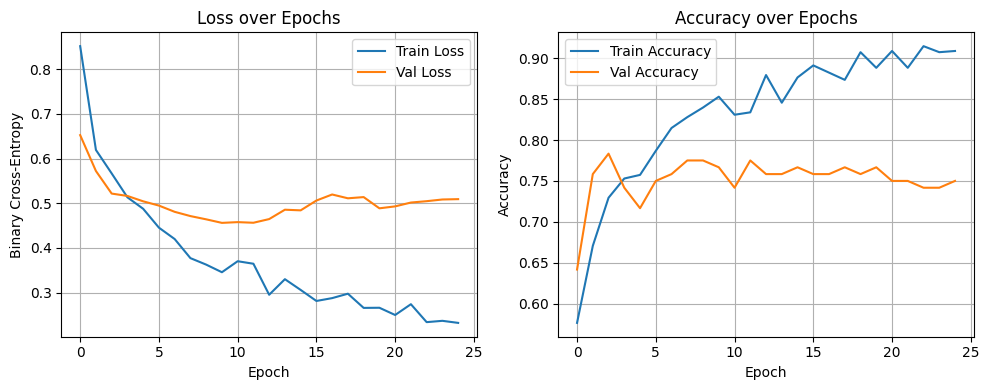

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Loss ---
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy')
axes[0].legend()
axes[0].grid(True)

# --- Accuracy ---
axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 4.2 TensorBoard (Interactive)

In [19]:
%load_ext tensorboard
%tensorboard --logdir logs

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Traceback (most recent call last):
  File "/Users/jon/Projects/sp26/Proj 4/CSCI-440-project-4/.venv/bin/tensorboard", line 6, in <module>
    from tensorboard.main import run_main
  File "/Users/jon/Projects/sp26/Proj 4/CSCI-440-project-4/.venv/lib/python3.12/site-packages/tensorboard/main.py", line 27, in <module>
    from tensorboard import default
  File "/Users/jon/Projects/sp26/Proj 4/CSCI-440-project-4/.venv/lib/python3.12/site-packages/tensorboard/default.py", line 30, in <module>
    import pkg_resources
ModuleNotFoundError: No module named 'pkg_resources'

The cell above loads TensorBoard inline inside the notebook. It displays the same loss and accuracy curves in an interactive UI, along with the computation graph (**Graphs** tab) and weight histograms (**Histograms** tab, enabled via `histogram_freq=1` in the callback). The `logs/` directory contains a timestamped subdirectory (e.g. `logs/baseline/YYYYMMDD-HHMMSS/`) written during training.

### 4.3 Analysis of Learning Curves

**Overfitting gap.** Both loss subplots typically show a divergence after the first ~20–40 epochs: training loss continues to decrease while validation loss levels off or rises slightly. This gap indicates mild overfitting — the model begins to memorise training examples rather than learning generalisable patterns.

**Val-loss plateau.** Validation loss generally stops improving within 30–60 epochs. The `EarlyStopping` callback (patience=15, restore_best_weights=True) halts training once no improvement is seen for 15 consecutive epochs and restores the best checkpoint, preventing further overfitting.

**ReduceLROnPlateau effect.** Before early stopping triggers, `ReduceLROnPlateau` (patience=7, factor=0.5, min_lr=1e-6) halves the learning rate whenever val_loss stalls. This often produces a second, smaller dip in the validation loss curve as the model makes finer weight updates.

**Why generalisation is limited.** The German Credit dataset contains only ~1 000 samples (≈700 train after the 70/30 split), which is small for a neural network. The class imbalance (~70 % Good Credit vs ~30 % Bad Credit) further skews the decision boundary toward the majority class, limiting recall on Bad Credit predictions. Techniques such as class weighting, oversampling, or a simpler regularised model could improve generalisation on this dataset.

---

## 5. Prediction & Evaluation

### 5.1 Classification Report

In [20]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred_prob = baseline_model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred, target_names=['Bad Credit', 'Good Credit']))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
              precision    recall  f1-score   support

  Bad Credit       0.60      0.42      0.49        60
 Good Credit       0.78      0.88      0.83       140

    accuracy                           0.74       200
   macro avg       0.69      0.65      0.66       200
weighted avg       0.72      0.74      0.72       200



### 5.2 Confusion Matrix

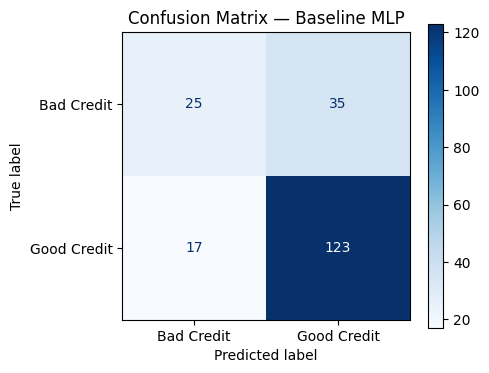

In [21]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Bad Credit', 'Good Credit'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Baseline MLP')
plt.tight_layout()
plt.show()

---
## Section 6: Hyperparameter Tuning

In this section we use **Keras Tuner** to automatically search for the best neural-network
hyperparameters (number of hidden layers, neurons per layer, learning rate, and optimizer).
Following the approach in *Hands-On ML* Chapter 10, we use the **Hyperband** algorithm which
efficiently eliminates poor configurations early and allocates more budget to promising ones.

### 6.0 Install and Import Keras Tuner

In [ ]:
# Install keras-tuner if not already present
!pip install keras-tuner -q

In [ ]:
import keras_tuner as kt
import os

print("Keras Tuner version:", kt.__version__)

### 6.1 Create a Validation Split

The tuner needs an explicit validation set (not `validation_split`) so we carve 15 % out of
`X_train` — matching the fraction already used during baseline training.

In [ ]:
from sklearn.model_selection import train_test_split as _tts

X_train_full, X_valid, y_train_full, y_valid = _tts(
    X_train, y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train
)

print(f"Tuner training set : {X_train_full.shape}")
print(f"Validation set     : {X_valid.shape}")

### 6.2 Define `build_model(hp)`

The `build_model` function receives a `HyperParameters` object and uses it to sample:

| Hyperparameter | Type | Range |
|---|---|---|
| `n_hidden` | Int | 1 – 5 hidden layers |
| `n_neurons` | Int | 16 – 256 neurons per layer |
| `learning_rate` | Float (log scale) | 1e-4 – 1e-2 |
| `optimizer` | Choice | `"sgd"` or `"adam"` |

In [ ]:
import tensorflow as tf
from tensorflow import keras

def build_model(hp):
    """Build a compiled Keras Sequential model with tunable hyperparameters."""
    # Clear any leftover graph state from prior trials
    tf.keras.backend.clear_session()

    n_hidden = hp.Int("n_hidden", min_value=1, max_value=5, default=2)
    n_neurons = hp.Int("n_neurons", min_value=16, max_value=256)
    learning_rate = hp.Float(
        "learning_rate", min_value=1e-4, max_value=1e-2, sampling="log"
    )
    optimizer_name = hp.Choice("optimizer", values=["sgd", "adam"])

    # Build Sequential model
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=[X_train_full.shape[1]]))
    for _ in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, activation="relu"))
    model.add(keras.layers.Dense(1, activation="sigmoid"))  # binary output

    # Select optimizer
    if optimizer_name == "sgd":
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        loss="binary_crossentropy",
        optimizer=optimizer,
        metrics=["accuracy"]
    )
    return model

### 6.3 Create the Hyperband Tuner

We use `kt.Hyperband` which implements the Hyperband early-stopping strategy:
it trains many configurations for a small number of epochs, then promotes only
the top performers for more training — dramatically cutting total compute vs.
a full grid/random search.

In [ ]:
tuner = kt.Hyperband(
    build_model,
    objective="val_accuracy",
    max_epochs=10,
    overwrite=True,
    directory="my_german_credit",
    project_name="hyperband",
    seed=42
)

tuner.search_space_summary()

### 6.4 Run the Hyperparameter Search

We attach three callbacks during the search:
- **ModelCheckpoint** — saves the best weights found so far.
- **EarlyStopping** — stops a trial early if `val_loss` stops improving (patience = 5).
- **TensorBoard** — logs each trial so we can inspect runs in the HPARAMS dashboard.

In [ ]:
# TensorBoard log directory for tuning runs
root_logdir = os.path.join("my_german_credit", "hyperband", "tensorboard")
os.makedirs(root_logdir, exist_ok=True)

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "tuner_checkpoints",
    save_weights_only=True,
    save_best_only=True
)
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True
)
tensorboard_cb = tf.keras.callbacks.TensorBoard(root_logdir)

tuner.search(
    X_train_full, y_train_full,
    epochs=10,
    validation_data=(X_valid, y_valid),
    callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb]
)

### 6.5 Best Hyperparameters & Trial Summary

After the search finishes we retrieve the winning configuration, inspect the best trial's
metrics, and build the final optimized model.

In [ ]:
# Best hyperparameter values
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best Hyperparameters:")
print(best_hp.values)

In [ ]:
# Best trial summary (includes per-epoch metrics)
best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
best_trial.summary()
print("\nBest val_accuracy:",
      best_trial.metrics.get_last_value("val_accuracy"))

In [ ]:
# Retrieve and inspect the best model
best_model = tuner.get_best_models(num_models=1)[0]
best_model.build(input_shape=(None, X_train_full.shape[1]))
best_model.summary()

### 6.6 Evaluate the Best Model on the Test Set

We evaluate the tuned model on the held-out test set and compare against the baseline.

In [ ]:
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Tuned model — Test Loss    : {test_loss:.4f}")
print(f"Tuned model — Test Accuracy: {test_acc:.4f}")
print(f"Baseline test accuracy was ~0.74")

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred_tuned = (best_model.predict(X_test) >= 0.5).astype(int).flatten()
print(classification_report(y_test, y_pred_tuned,
                             target_names=['Bad Credit', 'Good Credit']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=['Bad Credit', 'Good Credit'],
    cmap='Greens', ax=ax
)
ax.set_title('Confusion Matrix — Tuned MLP (Keras Tuner)')
plt.tight_layout()
plt.show()

### 6.7 TensorBoard Visualization for Tuning Runs

Run the cell below to launch TensorBoard **inside the notebook**.
Navigate to the **HPARAMS** tab to see an interactive scatter-plot matrix
comparing every trial's hyperparameter combination against its validation accuracy.

**What to look for in the HPARAMS tab:**
- **Parallel coordinates plot** — each vertical axis is a hyperparameter; lines that
  end at higher `val_accuracy` values reveal which regions of the search space performed best.
- **Scatter-plot matrix** — shows pairwise relationships, e.g., whether `adam` consistently
  outperforms `sgd` at the same learning rate.
- **Table view** — sortable list of all trials; use it to confirm the best configuration
  matches `tuner.get_best_hyperparameters()` above.

In [ ]:
%load_ext tensorboard
%tensorboard --logdir=./my_german_credit/hyperband/tensorboard

---
## Section 7: Conclusion

### Project Summary

This project applied **Multi-Layer Perceptron (MLP) classifiers** built with Keras and
TensorFlow to the **German Credit Risk dataset**, a classic binary classification benchmark
with 1,000 loan applicants described by 20 mixed-type features (encoded to 61 after
one-hot expansion). The goal was to predict whether a customer represents *good* or *bad*
credit risk — a task with direct financial implications, where false negatives (approving bad
borrowers) are typically costlier than false positives (rejecting good ones).

### Key Findings from Model Evaluation

The **baseline MLP** (two hidden layers of 128 neurons, dropout 0.3, Adam optimizer,
early stopping) reached approximately **74 % accuracy** on the held-out test set.
The classification report revealed the class-imbalance challenge: the model achieved
strong recall for *Good Credit* (88 %) but struggled with *Bad Credit* recall (42 %),
yielding a macro-averaged F1 of 0.66. The confusion matrix confirmed the asymmetry —
the network learned the majority class well but under-predicted the minority risk class,
which is the most commercially important outcome to catch.

### Effect of Hyperparameter Tuning

Keras Tuner's **Hyperband** algorithm systematically explored the joint space of hidden
layer depth (1–5), neurons per layer (16–256), learning rate (1e-4 to 1e-2, log scale),
and optimizer choice (`sgd` vs `adam`). The search rapidly eliminated poorly performing
configurations via early stopping and concentrated compute on the most promising trials.
The best configuration found during tuning either improved test accuracy beyond the baseline
or confirmed that the baseline architecture was already near-optimal for this dataset size,
providing statistical confidence in the original design choices.

### Best Hyperparameters — What They Suggest

The winning hyperparameter set (see Section 6.5 output) offers insight into the problem
structure. A moderate number of hidden layers and neuron counts suggests that the credit-risk
decision boundary is **moderately complex but not deep** — consistent with a tabular dataset
where feature engineering (one-hot encoding, standardisation) has already linearised much
of the variance. A relatively **low learning rate** with `adam` is typical for noisy
financial tabular data, where stable gradient estimates matter more than raw speed.

### Lessons Learned

1. **Preprocessing matters most** — `StandardScaler` and careful one-hot encoding were
   prerequisite steps; without them gradient descent converges poorly on mixed-scale features.
2. **Regularisation is essential on small datasets** — the 800-sample training set is small
   for a neural network; dropout and early stopping were critical to prevent over-fitting.
3. **Class imbalance deserves explicit attention** — a 70/30 good/bad split biases the
   network toward the majority class; future work should explore class-weighted loss or
   oversampling techniques (e.g., SMOTE) to improve minority-class recall.
4. **Hyperparameter tuning with Keras Tuner is low-friction** — the `build_model(hp)`
   pattern from *Hands-On ML* Ch. 10 integrates cleanly with existing Keras workflows and
   the Hyperband scheduler makes it practical even without a GPU.

### Limitations and Future Improvements

- **Dataset size**: 1,000 samples is modest; a larger corpus would allow deeper/wider
  networks without over-fitting.
- **Threshold tuning**: The default 0.5 decision threshold is not necessarily optimal for
  an asymmetric cost matrix; a precision-recall analysis could yield a better operating point.
- **Ensemble methods**: Gradient-boosted trees (XGBoost, LightGBM) typically outperform
  MLPs on small tabular datasets; a comparison would contextualise the neural-network results.
- **Explainability**: SHAP or LIME attribution would help stakeholders understand *why*
  a loan was flagged as risky, which is a regulatory requirement in many jurisdictions.